# Step 2: Exploratory and Baseline Analysis

This notebook studies the frozen PSLV launch dataset before Bayesian modeling. It describes the historical success rate, uncertainty, failure spacing, consecutive failures, temporal patterns, rolling rates, variants, and sensitivity checks.

**Important:** this notebook does not prove that PSLV reliability changed. Formal Bayesian modeling belongs to Step 3 and Step 4.

## Mathematical roadmap

We represent launch `i` by a binary outcome:

$Y_i = 1$ for success and $Y_i = 0$ for failure, with $i=1,2,\ldots,64$.\n
Let $n=64$ be the number of launches, $s=60$ the number of successes, and $f=4$ the number of failures. Step 2 describes the observed sequence. It does not estimate a Bayesian posterior.

The constant-rate reference statement is $Y_i\sim\operatorname{Bernoulli}(p)$, where $p$ is an unknown but constant success probability. The observed estimate is $\hat p=s/n=60/64=0.9375$. This reference statement prepares Step 3; it is not a conclusion that reliability is constant.

## 1. Load the frozen input

The only statistical input is `data/PSLV_verified_dataset_v1.0.csv`. The notebook never edits that file.

In [1]:
from pathlib import Path
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from scipy.stats import beta

# The notebook finds the project root whether it is opened from the root or code folder.
HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == 'code' else HERE
INPUT_FILE = PROJECT_ROOT / 'data' / 'PSLV_verified_dataset_v1.0.csv'
FIGURES_DIR = PROJECT_ROOT / 'figures'

def wilson_interval(successes, total):
    z = 1.959963984540054
    p = successes / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    width = z * math.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denominator
    return centre - width, centre + width

def runs_test(outcomes):
    n = len(outcomes); successes = sum(outcomes); failures = n - successes
    runs = 1 + sum(outcomes[i] != outcomes[i - 1] for i in range(1, n))
    expected = 1 + 2 * successes * failures / n
    return {'runs_observed': runs, 'runs_expected': expected}

def exact_runs_p_value(outcomes):
    # Count every binary ordering with the same 60 successes and 4 failures.
    # The p-value is the probability of observing this many or fewer runs.
    from functools import lru_cache
    from math import comb
    successes = sum(outcomes); failures = len(outcomes) - successes
    observed_runs = 1 + sum(outcomes[i] != outcomes[i - 1] for i in range(1, len(outcomes)))
    @lru_cache(None)
    def count(s_left, f_left, last, runs_left):
        if s_left == 0 and f_left == 0: return int(runs_left == 0)
        total = 0
        if s_left and last == 1: total += count(s_left - 1, f_left, 1, runs_left)
        if f_left and last == 0: total += count(s_left, f_left - 1, 0, runs_left)
        if s_left and last != 1: total += count(s_left - 1, f_left, 1, runs_left - 1)
        if f_left and last != 0: total += count(s_left, f_left - 1, 0, runs_left - 1)
        return total
    counts = {}
    for starting_value in (0, 1):
        s_left = successes - int(starting_value == 1)
        f_left = failures - int(starting_value == 0)
        if s_left >= 0 and f_left >= 0:
            for run_number in range(1, len(outcomes) + 1):
                counts[run_number] = counts.get(run_number, 0) + count(s_left, f_left, starting_value, run_number - 1)
    total_orderings = comb(len(outcomes), successes)
    exact_p = sum(value for run_number, value in counts.items() if run_number <= observed_runs) / total_orderings
    return observed_runs, exact_p

def check_input(data):
    errors = []
    if len(data) != 64: errors.append(f'Expected 64 rows, found {len(data)}')
    if list(data['launch_index']) != list(range(1, len(data) + 1)): errors.append('launch_index is not 1 through 64')
    if data['mission'].duplicated().any(): errors.append('Duplicate missions found')
    if not data['calendar_date'].is_monotonic_increasing: errors.append('Dates are not chronological')
    if not set(data['success'].unique()).issubset({0, 1}): errors.append('success is not binary')
    if int((data['success'] == 0).sum()) != 4: errors.append('Expected four failures')
    if int(data.loc[data['mission'] == 'PSLV-C62', 'previous_failure'].iloc[0]) != 1: errors.append('C62 previous_failure is not 1')
    return errors

data = pd.read_csv(INPUT_FILE)
data['calendar_date'] = pd.to_datetime(data['calendar_date'])
errors = check_input(data)
if errors: raise ValueError(errors)

# Add cumulative, rolling, and calendar-time variables.
data['cumulative_success_rate'] = data['success'].cumsum() / data['launch_index']
data['cumulative_failures'] = (1 - data['success']).cumsum()
data['previous_success'] = data['success'].shift(1)
data['consecutive_failure'] = ((data['success'] == 0) & (data['previous_success'] == 0)).astype(int)
data['calendar_gap_days'] = data['calendar_date'].diff().dt.days
for window in (10, 15, 20): data[f'rolling_success_{window}'] = data['success'].rolling(window).mean()

failure_rows = data[data['success'] == 0].copy()
failure_rows['failure_number'] = range(1, len(failure_rows) + 1)
failure_rows['previous_outcome'] = failure_rows['previous_success'].map({1.0: 'SUCCESS', 0.0: 'FAILURE'}).fillna('NONE')
failure_rows['gap_from_previous_failure'] = failure_rows['launch_index'].diff()
failure_gaps = failure_rows[['failure_number', 'launch_index', 'mission', 'calendar_date', 'previous_outcome', 'gap_from_previous_failure']]

transition = data[data['launch_index'] > 1].copy()
transition['previous_outcome'] = transition['previous_success'].map({1.0: 'SUCCESS', 0.0: 'FAILURE'})
transition['current_outcome'] = transition['success'].map({1: 'SUCCESS', 0: 'FAILURE'})
transition_counts = transition.groupby(['previous_outcome', 'current_outcome'], as_index=False).size().rename(columns={'size': 'count'})

periods = []
for start, end, label in [(1, 20, '1-20'), (21, 40, '21-40'), (41, 60, '41-60'), (61, 64, '61-64')]:
    part = data[data['launch_index'].between(start, end)]
    periods.append({'period': label, 'launches': len(part), 'successes': int(part['success'].sum()), 'failures': int((part['success'] == 0).sum()), 'success_rate': part['success'].mean()})
period_summary = pd.DataFrame(periods)
variant_summary = data.groupby('variant_standard', as_index=False).agg(launches=('success', 'size'), successes=('success', 'sum'), failures=('success', lambda x: int((x == 0).sum())))
variant_summary['success_rate'] = variant_summary['successes'] / variant_summary['launches']
first_62 = data.iloc[:62]
recent_2 = data.iloc[62:]
sensitivity_rows = [
    {'analysis': 'All launches', 'removed_mission': '', 'launches': len(data), 'failures': int((data['success'] == 0).sum()), 'success_rate': data['success'].mean()},
    {'analysis': 'Exclude C61 and C62', 'removed_mission': 'PSLV-C61;PSLV-C62', 'launches': len(first_62), 'failures': int((first_62['success'] == 0).sum()), 'success_rate': first_62['success'].mean()},
    {'analysis': 'Recent C61 and C62', 'removed_mission': '', 'launches': len(recent_2), 'failures': int((recent_2['success'] == 0).sum()), 'success_rate': recent_2['success'].mean()},
]
for _, failure in failure_rows.iterrows():
    remaining = data[data['mission'] != failure['mission']]
    sensitivity_rows.append({'analysis': 'Leave one failure out', 'removed_mission': failure['mission'], 'launches': len(remaining), 'failures': int((remaining['success'] == 0).sum()), 'success_rate': remaining['success'].mean()})
sensitivity = pd.DataFrame(sensitivity_rows)

lower, upper = wilson_interval(int(data['success'].sum()), len(data))
run_results = runs_test(data['success'].astype(int).tolist())
exact_runs_observed, exact_runs_p = exact_runs_p_value(data['success'].astype(int).tolist())
failure_after_failure = int(((data['previous_success'] == 0) & (data['success'] == 0)).sum())
failure_opportunities = int((data['previous_success'] == 0).sum())
failure_after_success = int(((data['previous_success'] == 1) & (data['success'] == 0)).sum())
success_opportunities = int((data['previous_success'] == 1).sum())
p_failure_after_failure = failure_after_failure / failure_opportunities
p_failure_after_success = failure_after_success / success_opportunities
baseline_statement = 'Y_i ~ Bernoulli(p), i = 1,...,64; p_hat = 60/64 = 0.9375'
summary = pd.DataFrame([
    {'statistic': 'Total launches', 'value': len(data)},
    {'statistic': 'Successes', 'value': int(data['success'].sum())},
    {'statistic': 'Failures', 'value': int((data['success'] == 0).sum())},
    {'statistic': 'Observed success proportion', 'value': data['success'].mean()},
    {'statistic': 'Wilson 95% lower success bound', 'value': lower},
    {'statistic': 'Wilson 95% upper success bound', 'value': upper},
    {'statistic': 'Consecutive failure transitions', 'value': int(data['consecutive_failure'].sum())},
    {'statistic': 'Failure after failure count', 'value': failure_after_failure},
    {'statistic': 'Failure after failure opportunities', 'value': failure_opportunities},
    {'statistic': 'P(failure after failure)', 'value': p_failure_after_failure},
    {'statistic': 'Failure after success count', 'value': failure_after_success},
    {'statistic': 'Failure after success opportunities', 'value': success_opportunities},
    {'statistic': 'P(failure after success)', 'value': p_failure_after_success},
    {'statistic': 'Exact runs observed', 'value': exact_runs_observed},
    {'statistic': 'Exact runs p-value (lower tail)', 'value': exact_runs_p},
    {'statistic': 'Constant-rate baseline', 'value': baseline_statement},
    *[{'statistic': key, 'value': value} for key, value in run_results.items()],
])
tables = {'analysis_data': data, 'summary': summary, 'failure_gaps': failure_gaps, 'transition_counts': transition_counts, 'period_summary': period_summary, 'variant_summary': variant_summary, 'sensitivity': sensitivity}
analysis_data = data
print(f'Input file: {INPUT_FILE}')
print(f'Rows: {len(data)}')
print('Validation: PASS')

Input file: d:\PSLV_Reliability\data\PSLV_verified_dataset_v1.0.csv
Rows: 64
Validation: PASS


## Mathematics: overall rates and Wilson interval

The observed success rate is

$$\hat p = \frac{s}{n} = \frac{60}{64}=0.9375=93.75\%.$$

The observed failure rate is $\hat q=f/n=4/64=0.0625=6.25\%$. These are descriptive sample proportions.

For the 95% Wilson interval, let $z=1.96$. The formula is

$$\frac{\hat p+z^2/(2n) \pm z\sqrt{\hat p(1-\hat p)/n+z^2/(4n^2)}}{1+z^2/n}.$$

Substituting $\hat p=0.9375$ and $n=64$ gives approximately $[0.8500,0.9754]$. The interval is an uncertainty interval for the underlying proportion under the binomial sampling description; it is not a guarantee about future launches.

## 2. Overall reliability and uncertainty

The observed success proportion is `successes / launches`. It describes these 64 observed launches; it is not automatically the true long-run reliability. The Wilson interval is used because only four launches failed.

In [2]:
summary = tables['summary']
display(summary)

success_rate = data['success'].mean()
failure_rate = 1 - success_rate
print(f'Observed success rate: {success_rate:.2%}')
print(f'Observed failure rate: {failure_rate:.2%}')

,statistic,value
0,Total launches,64
1,Successes,60
2,Failures,4
3,Observed success proportion,0.9375
4,Wilson 95% lower success bound,0.850025
5,Wilson 95% upper success bound,0.975429
6,Consecutive failure transitions,1
7,Failure after failure count,1
8,Failure after failure opportunities,3
9,P(failure after failure),0.333333


Observed success rate: 93.75%
Observed failure rate: 6.25%


## Mathematics: cumulative reliability

At launch $t$, the cumulative number of successes is $S_t=\sum_{i=1}^{t}Y_i$. The cumulative success rate is

$$\hat p_t = \frac{S_t}{t}=\frac{\sum_{i=1}^{t}Y_i}{t}.$$

For example, $\hat p_1=Y_1$ and $\hat p_{64}=60/64=0.9375$. The curve is descriptive: a downward movement means the newly added launch was a failure, not that a permanent reliability change has been proven.

## 3. Launch sequence and cumulative reliability

Failures occur at launch indices 1, 41, 63, and 64. The last two observations are consecutive failures. The cumulative curve shows how the observed rate changes as launches accumulate.

,launch_index,mission,calendar_date,previous_failure
0,1,PSLV-D1,1993-09-20,0
40,41,PSLV-C39,2017-08-31,0
62,63,PSLV-C61,2025-05-18,0
63,64,PSLV-C62,2026-01-12,1


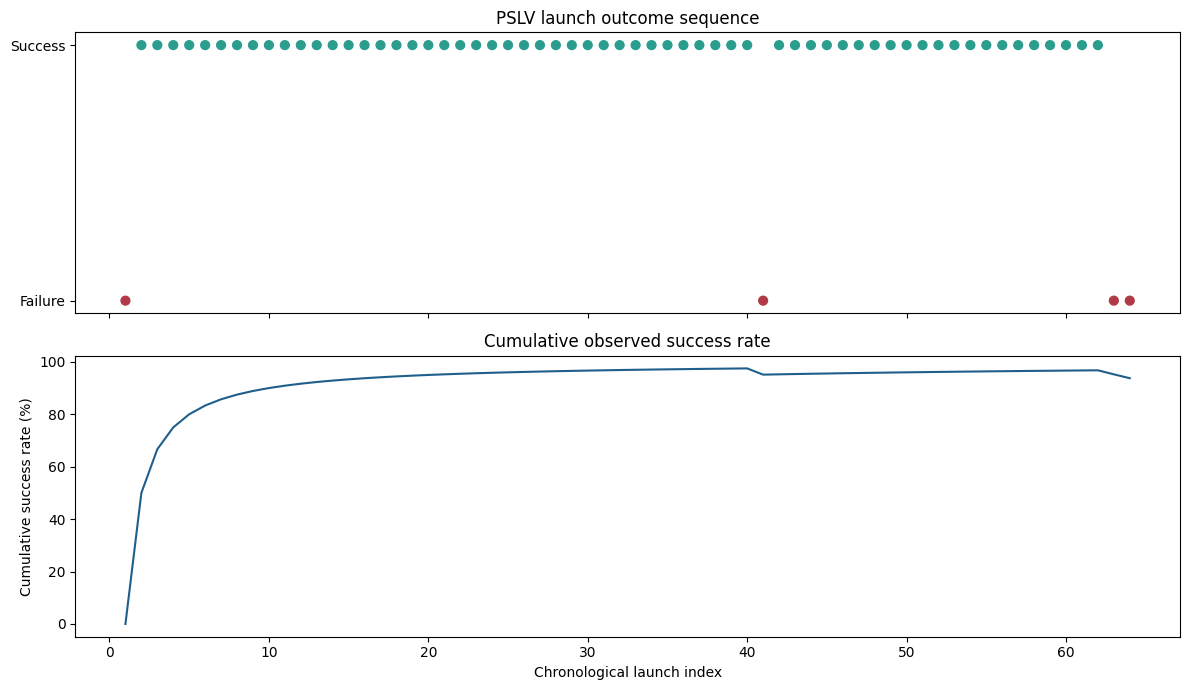

In [3]:
analysis_data = tables['analysis_data']
display(analysis_data.loc[analysis_data['success'] == 0, ['launch_index', 'mission', 'calendar_date', 'previous_failure']])

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].scatter(analysis_data['launch_index'], analysis_data['success'], c=analysis_data['success'].map({1: '#2a9d8f', 0: '#b23a48'}), s=40)
axes[0].set_yticks([0, 1], ['Failure', 'Success'])
axes[0].set_title('PSLV launch outcome sequence')
axes[1].plot(analysis_data['launch_index'], analysis_data['cumulative_success_rate'] * 100, color='#1f5f8b')
axes[1].set_xlabel('Chronological launch index')
axes[1].set_ylabel('Cumulative success rate (%)')
axes[1].set_title('Cumulative observed success rate')
plt.tight_layout()
plt.show()

## Mathematics: failure gaps and transitions

The failure indices are $F=(1,41,63,64)$. The gap between consecutive failures is

$$G_j=F_j-F_{j-1},$$

so $G=(41-1,63-41,64-63)=(40,22,1)$.

For transitions, compare $Y_{t-1}$ with $Y_t$. The consecutive-failure indicator is

$$C_t=I(Y_{t-1}=0,Y_t=0).$$

Here the count is 1, because C61 and C62 are both failures. The conditional estimates are $P(F_t\mid F_{t-1})=1/3=0.3333$ because there are 3 previous-failure opportunities, and $P(F_t\mid S_{t-1})=2/60=0.0333$ because there are 60 previous-success opportunities. The first estimate is very uncertain because its denominator is only 3.

## 4. Failure spacing and transitions

The inter-failure gaps are 40, 22, and 1 launches. Transition counts show how often each outcome follows the previous outcome. These are descriptive diagnostics, not strong tests, because there are only four failures.

,failure_number,launch_index,mission,calendar_date,previous_outcome,gap_from_previous_failure
0,1,1,PSLV-D1,1993-09-20,NONE,NaN
40,2,41,PSLV-C39,2017-08-31,SUCCESS,40.0
62,3,63,PSLV-C61,2025-05-18,SUCCESS,22.0
63,4,64,PSLV-C62,2026-01-12,FAILURE,1.0


,previous_outcome,current_outcome,count
0,FAILURE,FAILURE,1
1,FAILURE,SUCCESS,2
2,SUCCESS,FAILURE,2
3,SUCCESS,SUCCESS,58


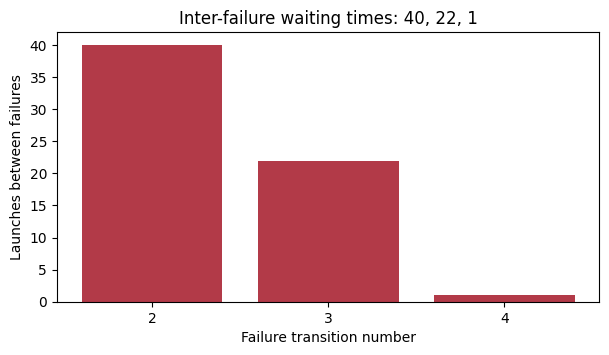

In [4]:
display(tables['failure_gaps'])
display(tables['transition_counts'])

gaps = tables['failure_gaps'].dropna(subset=['gap_from_previous_failure'])
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(gaps['failure_number'].astype(int).astype(str), gaps['gap_from_previous_failure'], color='#b23a48')
ax.set_xlabel('Failure transition number')
ax.set_ylabel('Launches between failures')
ax.set_title('Inter-failure waiting times: 40, 22, 1')
plt.show()

## Mathematics: runs and rolling windows

A run is a maximal consecutive group of equal outcomes. The observed sequence has 5 runs. The exact runs diagnostic fixes the margins at 60 successes and 4 failures, counts every binary ordering with those margins, and calculates

$$p_{exact}=P(R\leq R_{observed}\mid n_S=60,n_F=4).$$

The notebook enumerates the number of orderings for each possible run count using a small recursion. It obtains $R_{observed}=5$ and $p_{exact}=0.0090$. This describes relatively clustered ordering conditional on the observed margins; it does not prove a change in reliability.

For a rolling window of width $w$, the local success rate at launch $t$ is

$$R_t^{(w)}=\frac{1}{w}\sum_{i=t-w+1}^{t}Y_i.$$

We use pre-specified $w=10,15,20$ so the window is not chosen after seeing the result.

## 5. Runs and rolling reliability

The runs diagnostic asks whether successes and failures are arranged like a random ordering with the same total counts. Because there are only four failures, the notebook uses an exact conditional lower-tail p-value, not the normal approximation. The rolling windows are pre-specified at 10, 15, and 20 launches so the window is not chosen after seeing the result.

,statistic,value
6,Consecutive failure transitions,1
8,Failure after failure opportunities,3
9,P(failure after failure),0.333333
11,Failure after success opportunities,60
12,P(failure after success),0.033333
13,Exact runs observed,5
14,Exact runs p-value (lower tail),0.009015
15,Constant-rate baseline,"Y_i ~ Bernoulli(p), i = 1,...,64; p_hat = 60/6..."
16,runs_observed,5
17,runs_expected,8.5


Exact runs p-value tests for unusually few runs, conditional on 60 successes and 4 failures.
Constant-rate baseline: Y_i ~ Bernoulli(p), i = 1,...,64; p_hat = 60/64 = 0.9375


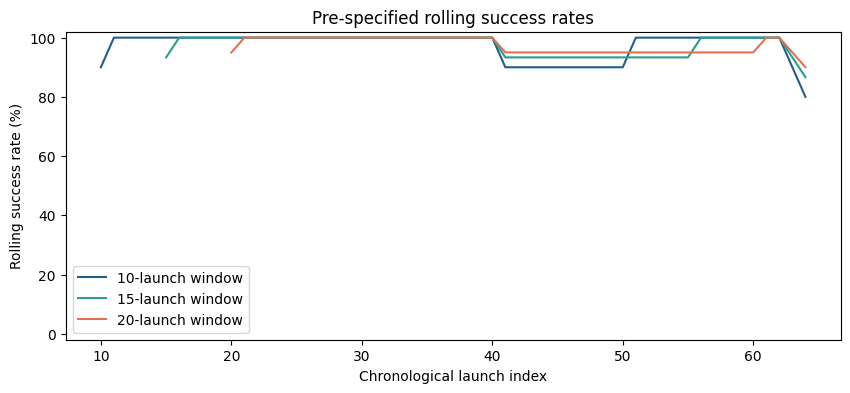

In [5]:
display(summary[summary['statistic'].str.contains('runs|Consecutive|P\(|baseline|opportunities', case=False, regex=True)])
print('Exact runs p-value tests for unusually few runs, conditional on 60 successes and 4 failures.')
print('Constant-rate baseline:', baseline_statement)

fig, ax = plt.subplots(figsize=(10, 4))
for window, color in [(10, '#1f5f8b'), (15, '#2a9d8f'), (20, '#e76f51')]:
    ax.plot(analysis_data['launch_index'], analysis_data[f'rolling_success_{window}'] * 100, label=f'{window}-launch window', color=color)
ax.set_xlabel('Chronological launch index')
ax.set_ylabel('Rolling success rate (%)')
ax.set_ylim(-2, 102)
ax.set_title('Pre-specified rolling success rates')
ax.legend()
plt.show()

## Mathematics: periods, calendar time, variants, and sensitivity

The pre-specified periods are launch indices 1-20, 21-40, 41-60, and 61-64. For any period with $n_k$ launches and $s_k$ successes, the period rate is $s_k/n_k$. The final period has only 4 launches, so its estimate is much less precise.

Calendar spacing is calculated as $\Delta t_i=t_i-t_{i-1}$ in days. This keeps launch-index time separate from calendar time.

Variant tables are descriptive counts only. With four failures, they must not be used to rank vehicle variants.

Sensitivity checks compare $60/64=93.75\%$ with $60/62=96.77\%$ after removing C61 and C62, and repeat the calculation after removing each failure one at a time.

## 6. Period, calendar, and variant summaries

The periods are fixed before looking at results: 1-20, 21-40, 41-60, and 61-64. The last period is very small. Variant results are descriptive only and should not be ranked.

,period,launches,successes,failures,success_rate
0,1-20,20,19,1,0.95
1,21-40,20,20,0,1.00
2,41-60,20,19,1,0.95
3,61-64,4,2,2,0.50


,variant_standard,launches,successes,failures,success_rate
0,PSLV,3,3,0,1.000000
1,PSLV-CA,14,14,0,1.000000
2,PSLV-DL,5,4,1,0.800000
3,PSLV-G,11,10,1,0.909091
4,PSLV-QL,2,2,0,1.000000
5,PSLV-XL,27,25,2,0.925926
6,UNKNOWN,2,2,0,1.000000


,analysis,removed_mission,launches,failures,success_rate
0,All launches,,64,4,0.937500
1,Exclude C61 and C62,PSLV-C61;PSLV-C62,62,2,0.967742
2,Recent C61 and C62,,2,2,0.000000
3,Leave one failure out,PSLV-D1,63,3,0.952381
4,Leave one failure out,PSLV-C39,63,3,0.952381
5,Leave one failure out,PSLV-C61,63,3,0.952381
6,Leave one failure out,PSLV-C62,63,3,0.952381


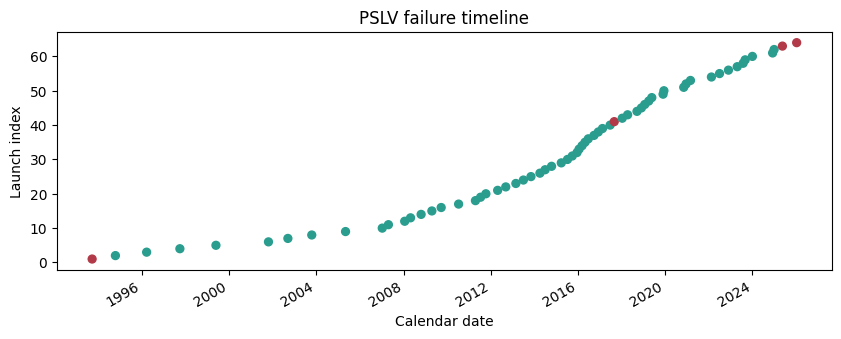

In [6]:
display(tables['period_summary'])
display(tables['variant_summary'])
display(tables['sensitivity'])

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.scatter(analysis_data['calendar_date'], analysis_data['launch_index'], c=analysis_data['success'].map({1: '#2a9d8f', 0: '#b23a48'}), s=32)
ax.set_xlabel('Calendar date')
ax.set_ylabel('Launch index')
ax.set_title('PSLV failure timeline')
fig.autofmt_xdate()
plt.show()

## 7. Reproducible figure files

The script creates the publication-oriented PNG files in `figures/`. This notebook displays them so they are easy to inspect.

step2_01_outcome_sequence.png


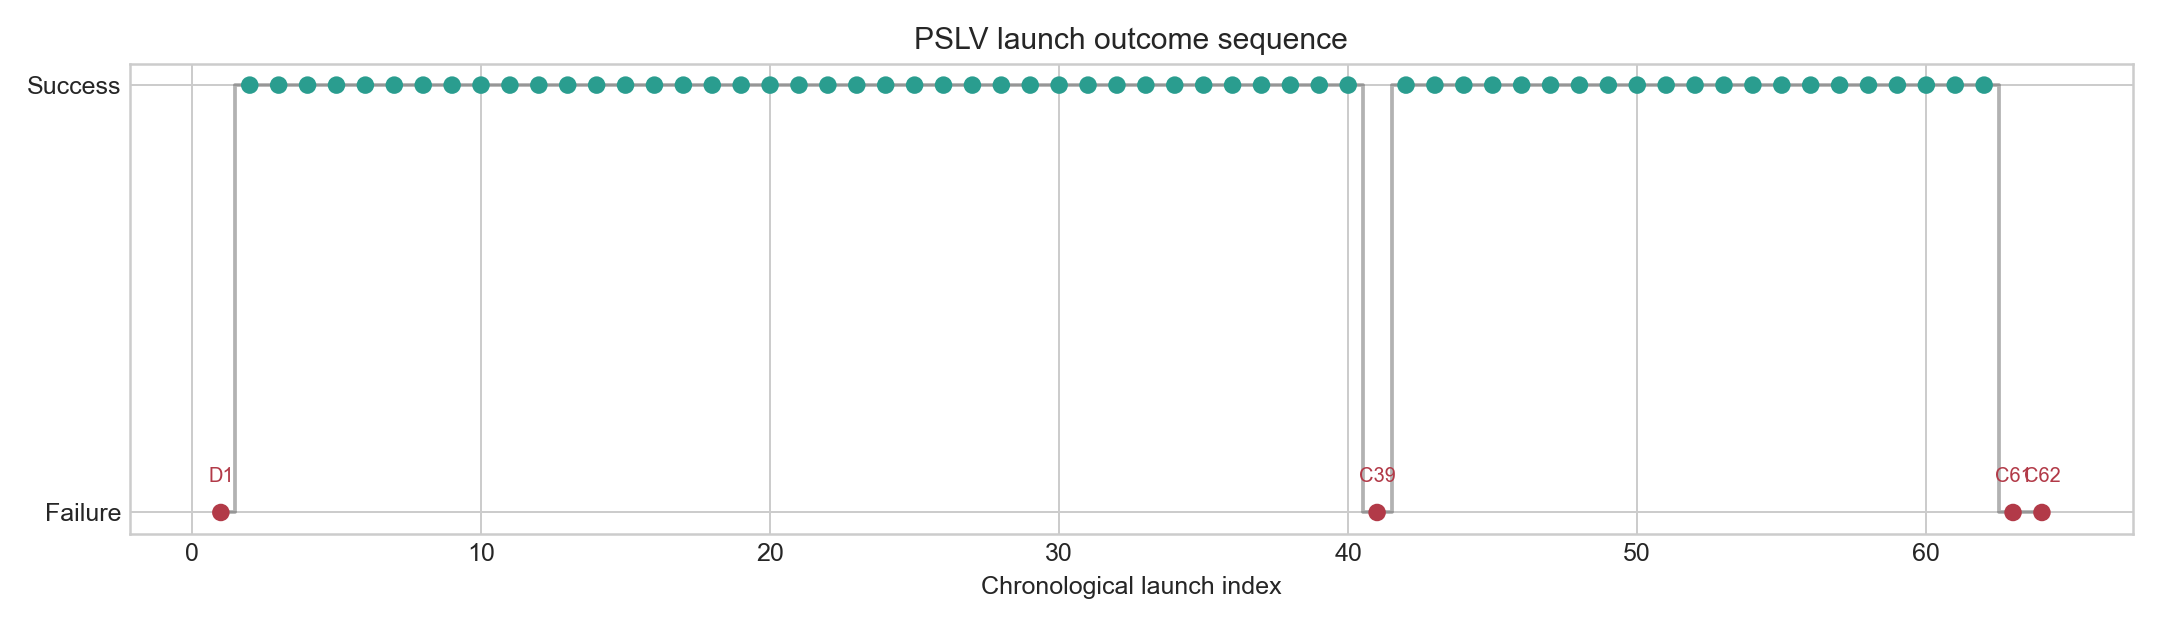

step2_02_cumulative_success.png


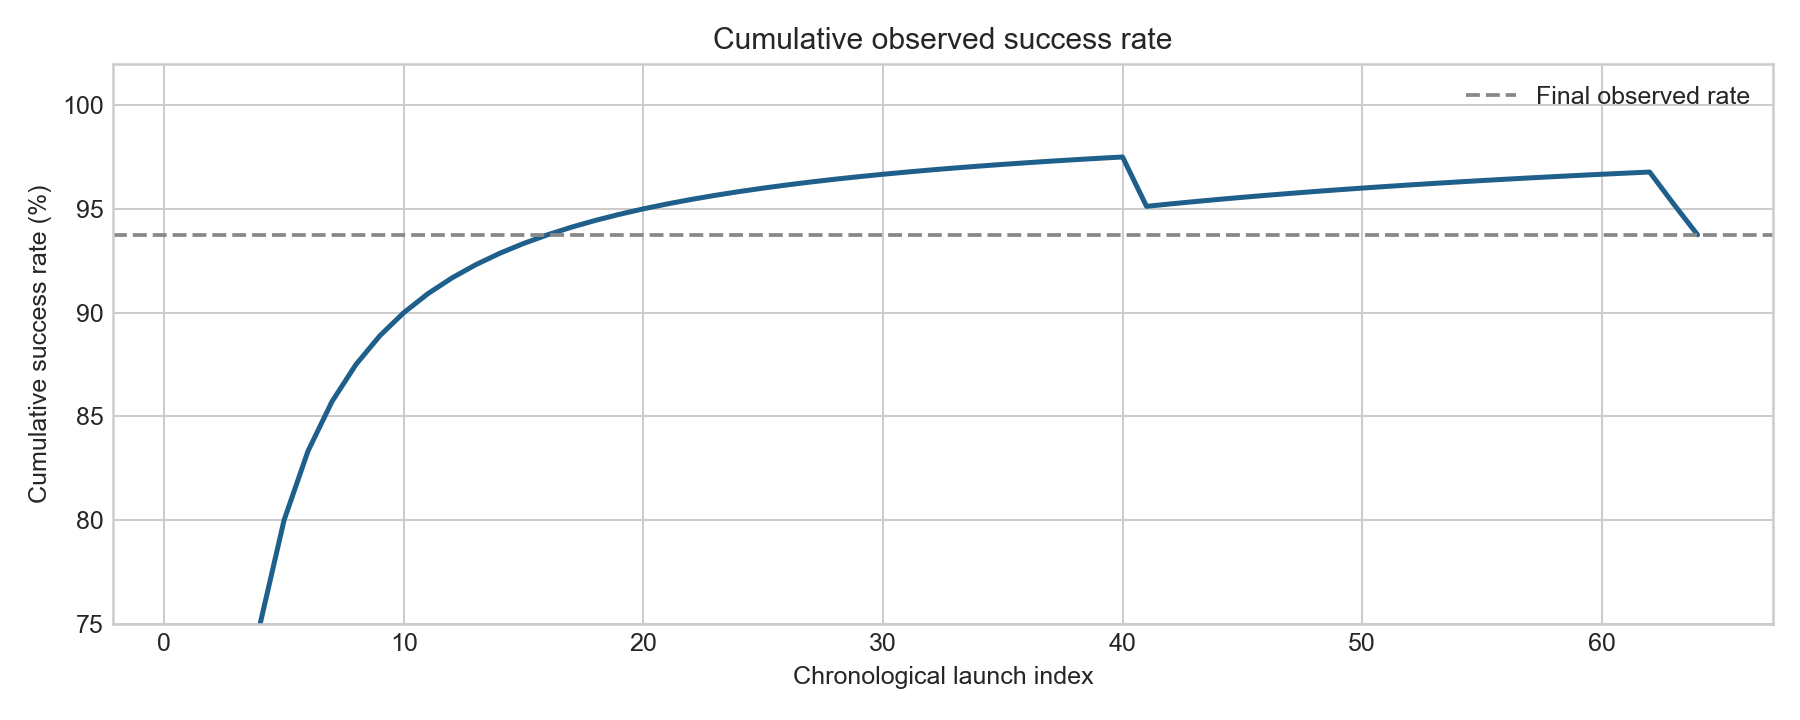

step2_03_rolling_success.png


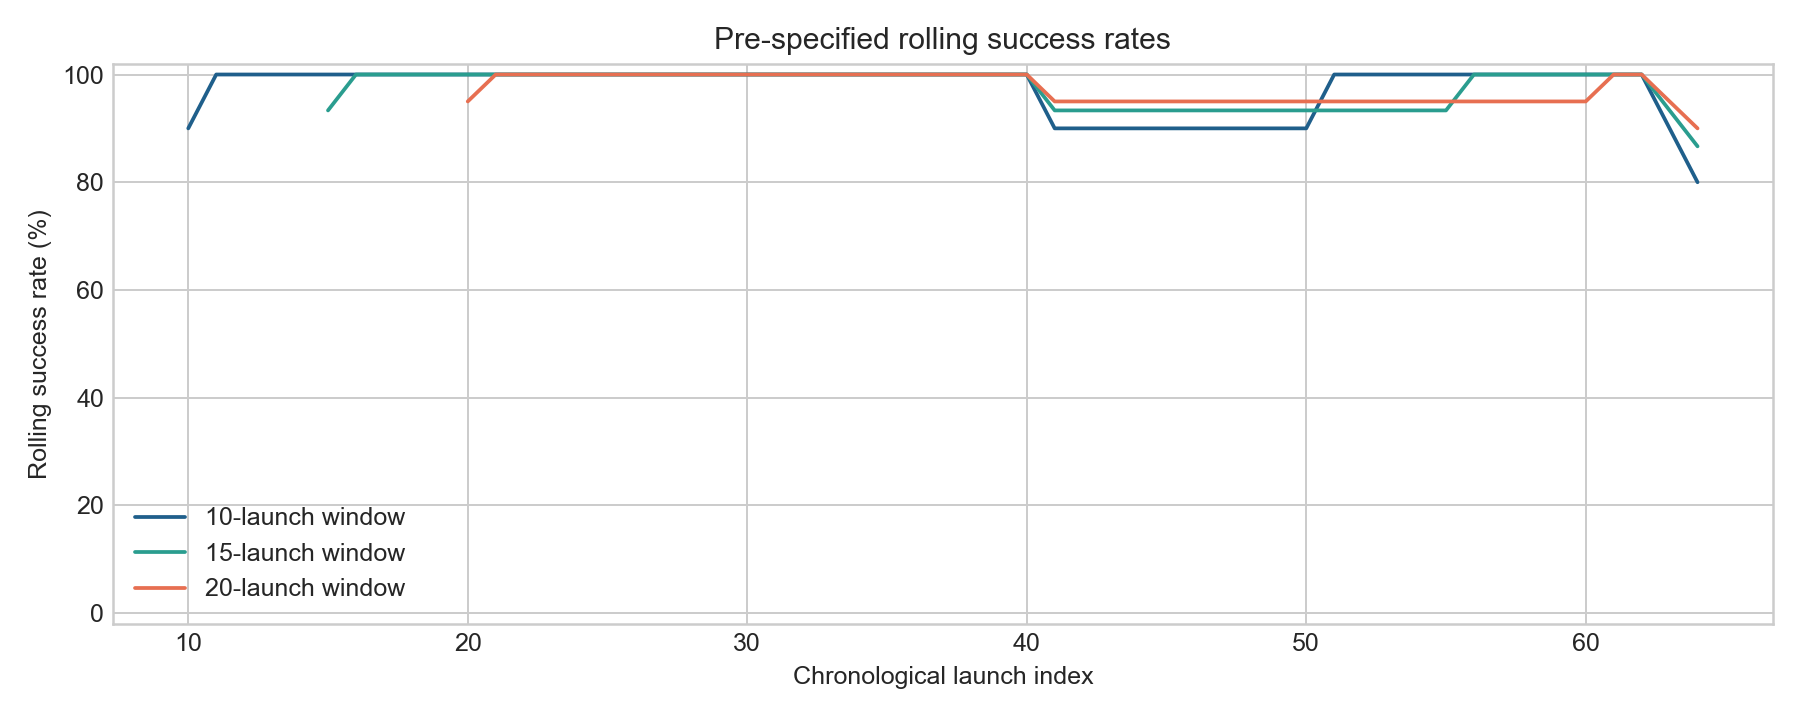

step2_04_failure_gaps.png


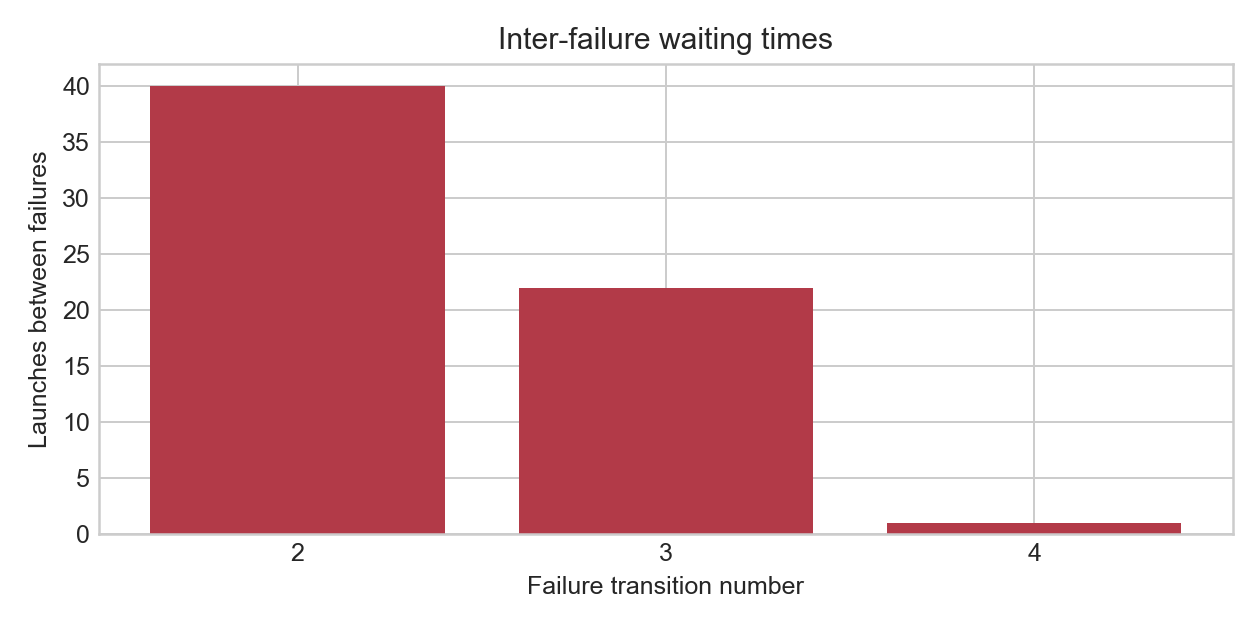

step2_05_failure_timeline.png


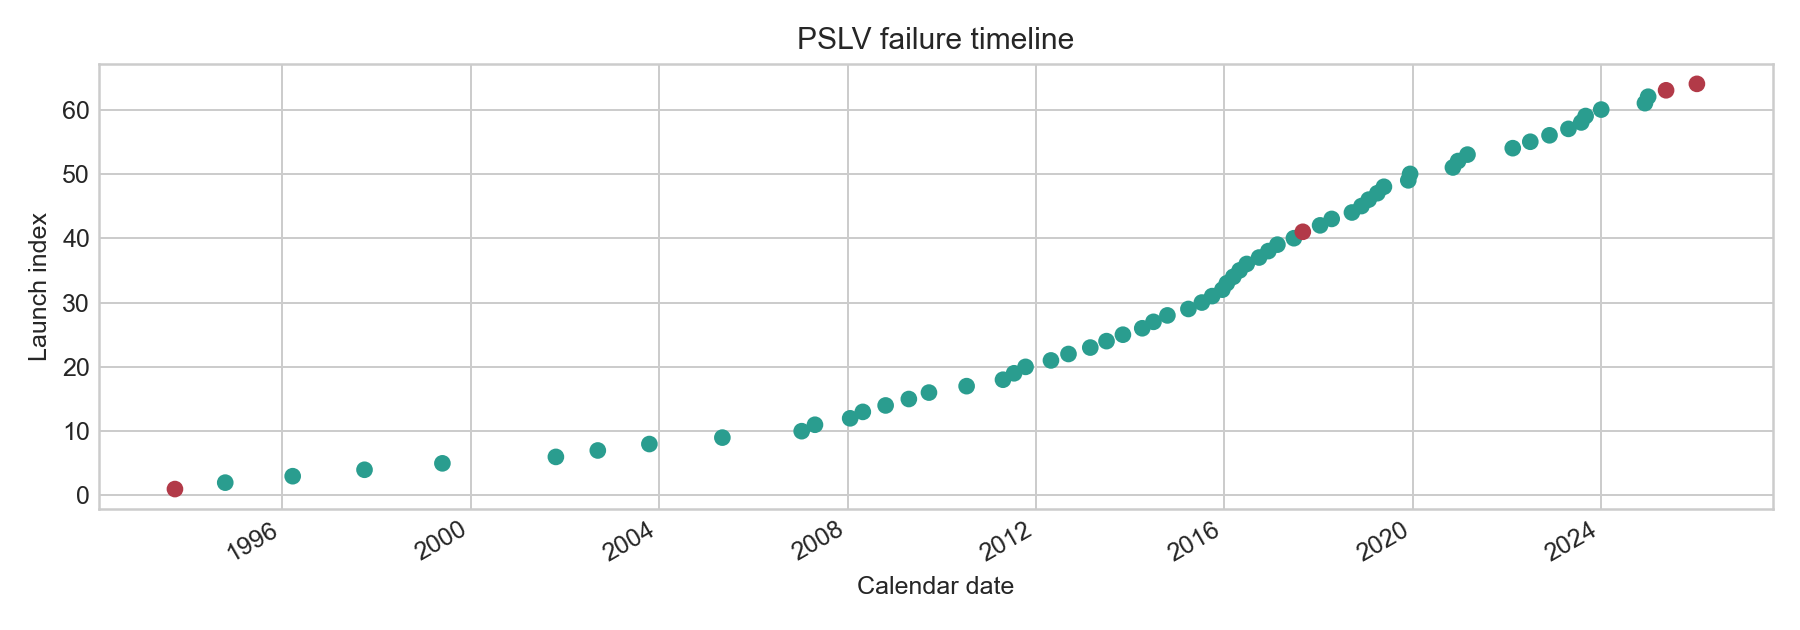

step2_06_cumulative_failures.png


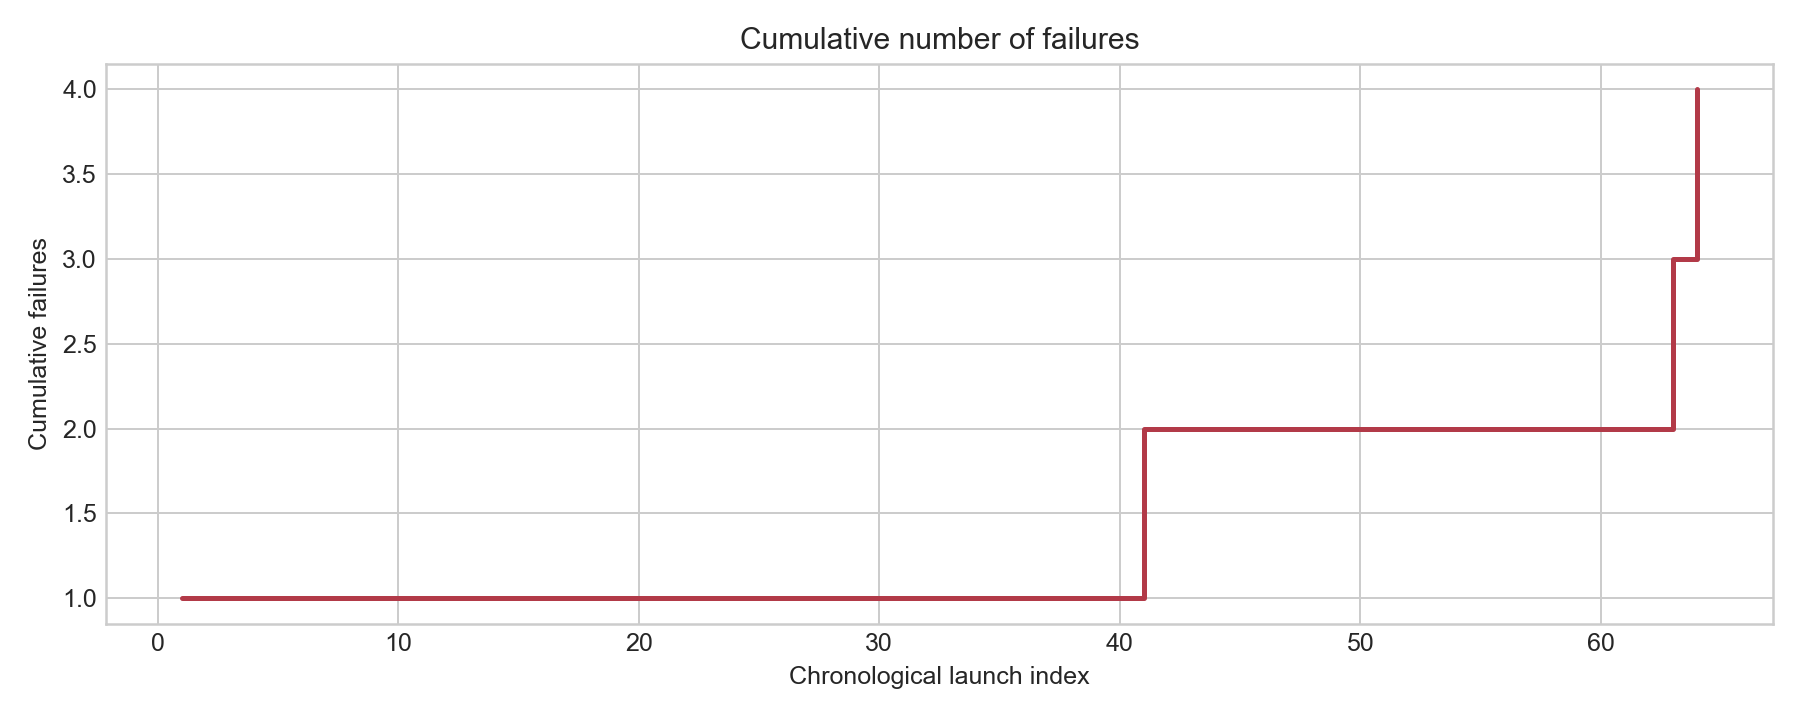

In [7]:
for figure_name in [
    'step2_01_outcome_sequence.png',
    'step2_02_cumulative_success.png',
    'step2_03_rolling_success.png',
    'step2_04_failure_gaps.png',
    'step2_05_failure_timeline.png',
    'step2_06_cumulative_failures.png',
]:
    print(figure_name)
    display(Image(filename=str(FIGURES_DIR / figure_name)))

In [8]:
# Save the main Step 2 tables and the updated report.
RESULTS_DIR = PROJECT_ROOT / 'results' / 'step2'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
rolling_reliability = data[['launch_index', 'mission', 'calendar_date', 'rolling_success_10', 'rolling_success_15', 'rolling_success_20']]
calendar_intervals = data[['launch_index', 'mission', 'calendar_date', 'calendar_gap_days']]
summary.to_csv(RESULTS_DIR / 'step2_summary.csv', index=False)
failure_gaps.to_csv(RESULTS_DIR / 'failure_gaps.csv', index=False)
rolling_reliability.to_csv(RESULTS_DIR / 'rolling_reliability.csv', index=False)
transition_counts.to_csv(RESULTS_DIR / 'transition_counts.csv', index=False)
variant_summary.to_csv(RESULTS_DIR / 'variant_summary.csv', index=False)
period_summary.to_csv(RESULTS_DIR / 'period_summary.csv', index=False)
calendar_intervals.to_csv(RESULTS_DIR / 'calendar_intervals.csv', index=False)
sensitivity.to_csv(RESULTS_DIR / 'sensitivity.csv', index=False)
report_lines = [
    '# Step 2 exploratory and baseline report', '',
    'This report was generated by the self-contained Step 2 notebook.', '',
    f'Launches: {len(data)}', f'Successes: {int(data.success.sum())}', f'Failures: {int((data.success == 0).sum())}',
    f'Observed success rate: {data.success.mean():.2%}', f'Wilson 95% interval: [{lower:.4f}, {upper:.4f}]',
    'Failure indices: 1, 41, 63, 64', 'Inter-failure gaps: 40, 22, 1',
    f'Exact runs lower-tail p-value: {exact_runs_p:.4f}', f'P(failure after failure): {p_failure_after_failure:.4f}',
    f'P(failure after success): {p_failure_after_success:.4f}', '',
    'Constant-rate baseline: Y_i ~ Bernoulli(p), i = 1,...,64, with p_hat = 0.9375.',
    'The exact runs result describes clustering conditional on the observed 60/4 margins. It does not establish that reliability changed.'
]
(RESULTS_DIR / 'step2_report.md').write_text('\n'.join(report_lines) + '\n', encoding='utf-8')
print(f'Saved Step 2 outputs to {RESULTS_DIR}')

Saved Step 2 outputs to d:\PSLV_Reliability\results\step2


,launch_index,mission,calendar_date,rolling_success_10,rolling_lower_10,rolling_upper_10,rolling_success_15,rolling_lower_15,rolling_upper_15,rolling_success_20,rolling_lower_20,rolling_upper_20
54,55,PSLV-C53,2022-06-30,1.0,0.715086,0.997701,0.933333,0.697679,0.984486,0.95,0.761840,0.988251
55,56,PSLV-C54,2022-11-26,1.0,0.715086,0.997701,1.000000,0.794093,0.998419,0.95,0.761840,0.988251
56,57,PSLV-C55,2023-04-22,1.0,0.715086,0.997701,1.000000,0.794093,0.998419,0.95,0.761840,0.988251
57,58,PSLV-C56,2023-07-30,1.0,0.715086,0.997701,1.000000,0.794093,0.998419,0.95,0.761840,0.988251
58,59,PSLV-C57,2023-09-02,1.0,0.715086,0.997701,1.000000,0.794093,0.998419,0.95,0.761840,0.988251
59,60,PSLV-C58,2024-01-01,1.0,0.715086,0.997701,1.000000,0.794093,0.998419,0.95,0.761840,0.988251
60,61,PSLV-C59,2024-12-05,1.0,0.715086,0.997701,1.000000,0.794093,0.998419,1.00,0.838902,0.998795
61,62,PSLV-C60,2024-12-30,1.0,0.715086,0.997701,1.000000,0.794093,0.998419,1.00,0.838902,0.998795
62,63,PSLV-C61,2025-05-18,0.9,0.587220,0.977169,0.933333,0.697679,0.984486,0.95,0.761840,0.988251
63,64,PSLV-C62,2026-01-12,0.8,0.482244,0.939782,0.866667,0.616524,0.959526,0.90,0.696226,0.969511


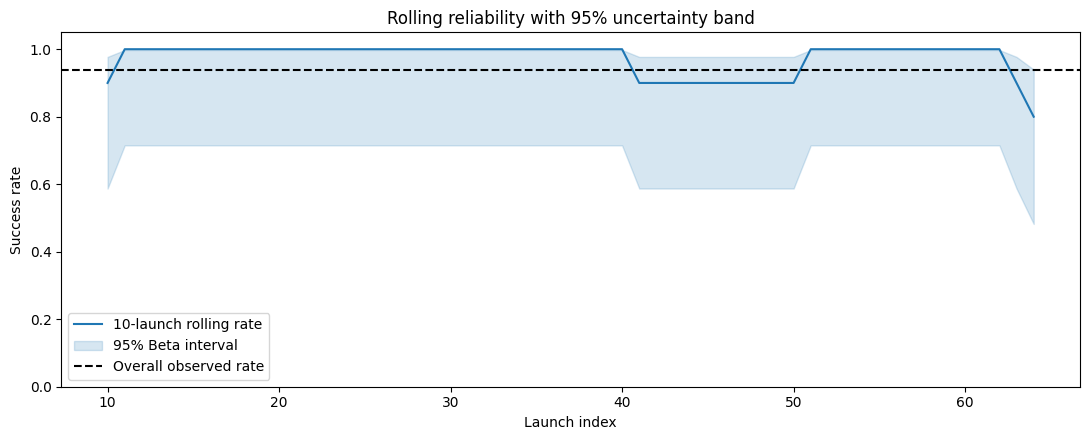

Saved rolling reliability uncertainty table and figure.


In [9]:
# Add uncertainty bands to the rolling reliability view.
rolling_with_intervals = data[['launch_index', 'mission', 'calendar_date']].copy()
for window in (10, 15, 20):
    successes_in_window = data['success'].rolling(window).sum()
    observations_in_window = data['success'].rolling(window).count()
    alpha_values = 1 + successes_in_window
    beta_values = 1 + observations_in_window - successes_in_window
    rolling_with_intervals[f'rolling_success_{window}'] = data['success'].rolling(window).mean()
    rolling_with_intervals[f'rolling_lower_{window}'] = beta.ppf(0.025, alpha_values, beta_values)
    rolling_with_intervals[f'rolling_upper_{window}'] = beta.ppf(0.975, alpha_values, beta_values)

display(rolling_with_intervals.tail(10))
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(data['launch_index'], data['rolling_success_10'], label='10-launch rolling rate', color='tab:blue')
ax.fill_between(data['launch_index'], rolling_with_intervals['rolling_lower_10'], rolling_with_intervals['rolling_upper_10'], color='tab:blue', alpha=0.18, label='95% Beta interval')
ax.axhline(data['success'].mean(), color='black', linestyle='--', label='Overall observed rate')
ax.set(xlabel='Launch index', ylabel='Success rate', title='Rolling reliability with 95% uncertainty band')
ax.set_ylim(0, 1.05); ax.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step2_07_rolling_uncertainty.png', dpi=180); plt.show()
rolling_with_intervals.to_csv(RESULTS_DIR / 'rolling_reliability_with_intervals.csv', index=False)
print('Saved rolling reliability uncertainty table and figure.')


,variant_standard,launches,failures,success_rate,warning
0,PSLV,3,0,1.000000,small group; descriptive only
1,PSLV-CA,14,0,1.000000,
2,PSLV-DL,5,1,0.800000,small group; descriptive only
3,PSLV-G,11,1,0.909091,
4,PSLV-QL,2,0,1.000000,small group; descriptive only
5,PSLV-XL,27,2,0.925926,
6,UNKNOWN,2,0,1.000000,small group; descriptive only


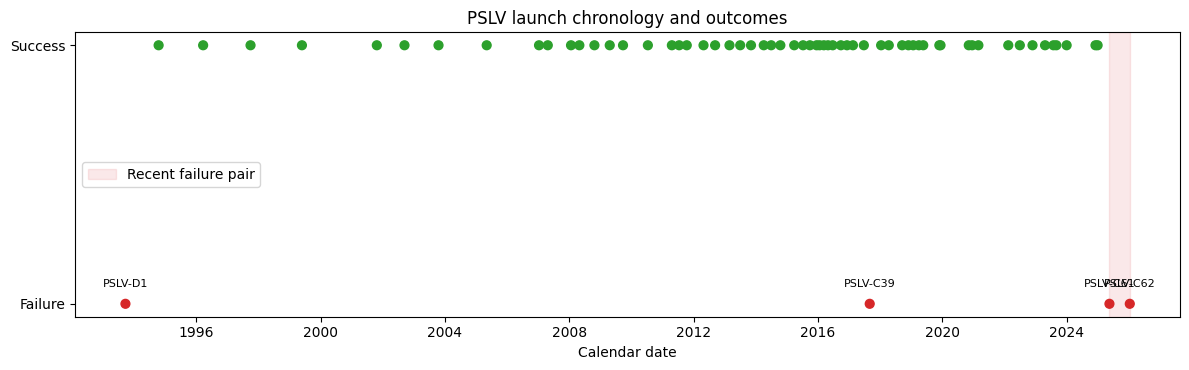

Saved calendar-time analysis, configuration summary, and chronology figure.


In [10]:
# Calendar-time and configuration summaries are descriptive sensitivity checks.
data['calendar_time_0_to_1'] = (data['calendar_date'] - data['calendar_date'].min()).dt.days / (data['calendar_date'].max() - data['calendar_date'].min()).days
configuration_summary = data.groupby('variant_standard', dropna=False).agg(launches=('success', 'size'), failures=('success', lambda values: int((values == 0).sum())), success_rate=('success', 'mean')).reset_index()
configuration_summary['warning'] = configuration_summary['launches'].apply(lambda value: 'small group; descriptive only' if value < 10 else '')
display(configuration_summary)
configuration_summary.to_csv(RESULTS_DIR / 'configuration_summary.csv', index=False)
data[['launch_index', 'mission', 'calendar_date', 'calendar_time_0_to_1', 'success', 'variant_standard']].to_csv(RESULTS_DIR / 'calendar_time_analysis.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.scatter(data['calendar_date'], data['success'], c=data['success'].map({1: 'tab:green', 0: 'tab:red'}), s=40)
for _, row in data[data['success'] == 0].iterrows():
    ax.annotate(row['mission'], (row['calendar_date'], row['success']), xytext=(0, 12), textcoords='offset points', ha='center', fontsize=8)
ax.axvspan(data.loc[data['mission'] == 'PSLV-C61', 'calendar_date'].iloc[0], data.loc[data['mission'] == 'PSLV-C62', 'calendar_date'].iloc[0], color='tab:red', alpha=0.10, label='Recent failure pair')
ax.set(yticks=[0, 1], yticklabels=['Failure', 'Success'], xlabel='Calendar date', title='PSLV launch chronology and outcomes')
ax.legend(); plt.tight_layout(); plt.savefig(FIGURES_DIR / 'step2_08_failure_chronology_publication.png', dpi=240); plt.show()
print('Saved calendar-time analysis, configuration summary, and chronology figure.')


## Step 2 conclusion

The observed record contains 60 successes and 4 failures among 64 launches. Failures occur at indices 1, 41, 63, and 64, with the final two failures consecutive. These descriptive results motivate later formal modeling, but they do not by themselves establish a change in the underlying reliability process.